In [30]:
import pandas as pd
import geopandas as gpd
# import geodatasets as gd
import matplotlib.pyplot as matplt

import seaborn as sns

url = "https://raw.githubusercontent.com/miab199/gwc-water/refs/heads/main/Self%20Supplied%20Industrial%20Water%20Use%20in%20the%20Tennessee%20Hydrologic%20Region%202010.csv?scrlybrkr=496e2411"
df = pd.read_csv(url)
df.head()


,County,Source of supply,Principal aquifer,Groundwater withdrawal (Mgal/d),Major river basin,Surface water withdrawal (Mgal/d)
0,Anderson,Clinch River,--,--,Upper Tennessee,0.524
1,Bradley,Hiwassee River,--,--,Middle Tennessee-Hiwassee,3.81
2,Carter,Well #1 & #2,Cambrian-Ordovician carbonate,0.134,--,--
3,Cocke,Well fields,Cambrian-Ordovician carbonate,0.214,--,--
4,Coffee,Well,Mississippian carbonate,0.020,--,--


In [31]:
numRows = len(df)
print("rows: ", numRows)

numColumns = len(df.columns)
print("columns: ", numColumns)

rows:  85
columns:  6


How concentrated is industrial water control in the Tennessee hydrologic region, and which communities bear the greatest extraction burden?
Cardinal Directions
Rural/Suburban/Urban
Which industrial sectors create the highest water stress relative to their geographic footprint?
3. Which counties are most structurally dependent on self-supplied industrial water, and what does that imply for long-term sustainability?

In [32]:
# looking for data about nas and nans
df.isna()

#find nas (axis 1 = rows, 0 = columns)
print(df.isna().any(axis=1))
# print(df.isna().sum(axis = 0 ))

0     False
1     False
2     False
3     False
4     False
      ...  
80     True
81     True
82     True
83     True
84     True
Length: 85, dtype: bool


In [33]:
df_clean = df.dropna()
df_clean

,County,Source of supply,Principal aquifer,Groundwater withdrawal (Mgal/d),Major river basin,Surface water withdrawal (Mgal/d)
0,Anderson,Clinch River,--,--,Upper Tennessee,0.524
1,Bradley,Hiwassee River,--,--,Middle Tennessee-Hiwassee,3.81
2,Carter,Well #1 & #2,Cambrian-Ordovician carbonate,0.134,--,--
3,Cocke,Well fields,Cambrian-Ordovician carbonate,0.214,--,--
4,Coffee,Well,Mississippian carbonate,0.020,--,--
...,...,...,...,...,...,...
58,Sullivan,South Fork of Holston River,--,--,French Broad-Holston,17.3
59,Sullivan,Holston River area B,--,--,French Broad-Holston,18.9
60,Sullivan,South Fork Holston River,--,--,French Broad-Holston,58.5
61,Sullivan,South Fork Holston River,--,--,French Broad-Holston,104


clean up NAs or NaNs (detect NAs and decide on removal)
how much water from rivers/wells?
how many unique aquifers?

In [34]:
df_surface = df_clean[df_clean["Groundwater withdrawal (Mgal/d)"] == "--"]
df_surface
num_surface = pd.to_numeric(df_surface["Surface water withdrawal (Mgal/d)"]).sum()
print("total surface water: ", num_surface)


total surface water:  703.7


In [35]:
df_ground = df_clean[df_clean["Surface water withdrawal (Mgal/d)"] == "--"]
df_ground
num_ground = pd.to_numeric(df_ground["Groundwater withdrawal (Mgal/d)"]).sum()
print("total ground water: ", num_ground)

total ground water:  6.4292


we found that there was a lot more surface water used, compared to ground water. There was 703.7 Mgal/d of surface water in total, and 6.4292 Mgal/d of ground water in total

In [36]:
num_rows_surface = len(df_surface)
avg_surface = num_surface / num_rows_surface
print("Average surface withdrawl: ", avg_surface)

Average surface withdrawl:  21.990625


In [37]:
num_rows_ground = len(df_ground)
avg_ground = num_ground / num_rows_ground
print("Average ground withdrawl: ", avg_ground)

Average ground withdrawl:  0.20739354838709675


They got more water from each surface withdrawl on average than each ground withdrawl on average. They got an average of 21.9906 Mgal/d of surface water and an average of 0.2074 Mgal/d of ground water.

In [38]:
print("number of unique surface water supply sources: ", df_surface['Source of supply'].nunique())

number of unique surface water supply sources:  20


In [39]:
print("number of unique ground water supply sources: ", df_ground['Source of supply'].nunique())

number of unique ground water supply sources:  18


there are 20 unique surface water sources and 18 unique ground water sources
BUT not necesarilly useful/correct info because some differences seem to by typos/stylistic choices

NameError: name 'plt' is not defined

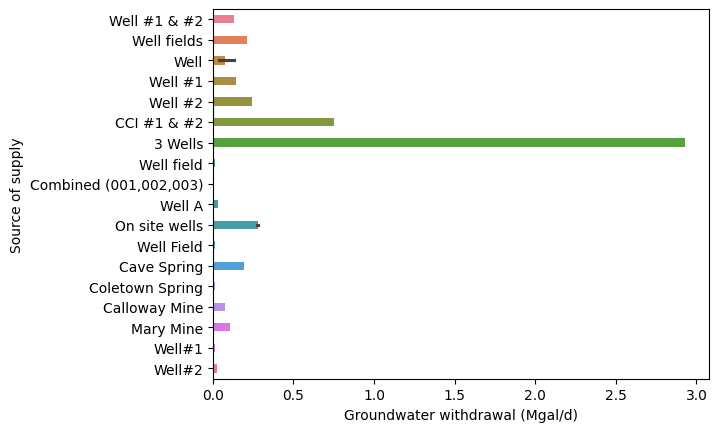

In [40]:
GW = pd.to_numeric(df_ground["Groundwater withdrawal (Mgal/d)"])
sns.barplot(df_ground, y = "Source of supply", x = GW, hue = "Source of supply", gap = 0.5, native_scale = False, orient = "y")
plt.set_title("Groundwater Withdrawl vs Supply Location")
plt.show()

next:

add for suface water - done
figure out what it means

<Axes: title={'center': 'Surface Water Withdrawl vs Supply Location'}, xlabel='Surface water withdrawal (Mgal/d)', ylabel='Source of supply'>

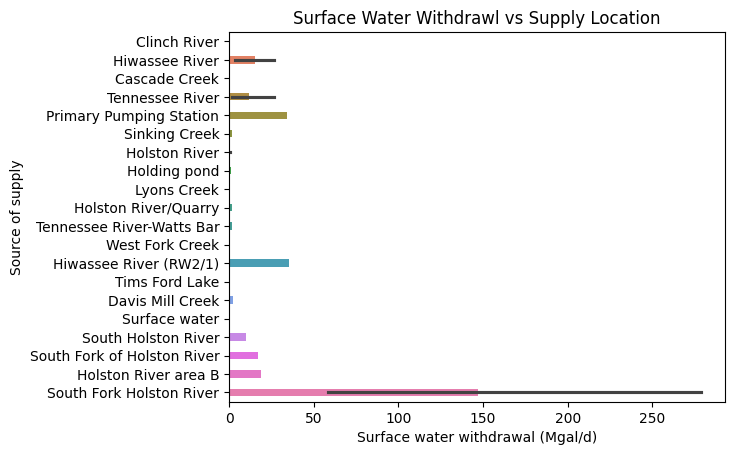

In [44]:
SW = pd.to_numeric(df_surface["Surface water withdrawal (Mgal/d)"])
plt_surface = sns.barplot(df_surface, y = "Source of supply", x = SW, hue = "Source of supply", gap = 0.5, native_scale = False, orient = "y")
plt_surface.set_title("Surface Water Withdrawl vs Supply Location")
plt_surface

In [41]:
# county_df_ground = df_ground[['County'], df_ground['Groundwater withdrawal (Mgal/d)']].copy()

# county_df_ground

In [49]:
df_grouped

NameError: name 'df_grouped' is not defined

In [43]:
data = {
    'County': ['Anderson', 'Bradley', 'Carter', 'Cocke', 'Coffee', 'Coffee', 'Franklin', 'Greene', 'Hamilton'],
    'Groundwater_withdrawal': [0.524, 0.0, 0.134, 0.214, 0.020, 0.023, 0.023, 0.0, 0.0002]
}
df = pd.DataFrame(data)

GroundW = pd.to_numeric(df_ground["Groundwater withdrawal (Mgal/d)"])


# # 2. Aggregate data by County (Summing multiple entries for one county, like Coffee)
df_grouped = df_ground.groupby('County')[GroundW].sum().reset_index()

# # # 3. Load Tennessee County Boundaries (GeoJSON)
# # # You can find TN county GeoJSONs from sources like the US Census or TN GIS portals
# tn_map_url = "https://raw.githubusercontent.com/miab199/gwc-water/refs/heads/main/TN_counties_2016.csv"
# tn_gdf = gpd.read_file(tn_map_url)

# # # 4. Merge the geographic data with your water data
# # # Note: Ensure county names match (e.g., "Hamilton" in both datasets)
# merged = tn_gdf.merge(df_grouped, left_on='NAME', right_on='County', how='left')

# # # 5. Plot the Choropleth Map
# fig, ax = matplt.subplots(1, 1, figsize=(12, 8))
# merged.plot(column='Groundwater withdrawal (Mgal/d)',
#             ax=ax,
#             legend=True,
#             cmap='Blues')
#             # missing_kwds={'color': 'lightgrey'}, # Counties with no data
#             # legend_kwds={'label': "Groundwater Withdrawal (Mgal/d)"})

# ax.set_title("Self-Supplied Industrial Groundwater Use by Tennessee County", fontsize=15)
# ax.axis('off')
# # matplotlib.pyplot.show()

KeyError: 'Columns not found: 0.134, 0.138, 0.365, 0.241, 0.754, 2.93, 0.277, 0.278, 0.193, 0.214, 0.027, 0.056, 0.023, 0.02, 0.145, 0.044, 0.047, 0.107, 0.072, 0.016, 0.078, 0.013, 0.014, 0.012, 0.041, 0.04, 0.0002, 0.091, 0.004, 0.032'